In [1]:
import yfinance as yf
import pandas as pd

tickers = ["TSLA", "BND", "SPY"]
start_date = "2015-01-01"
end_date = "2026-06-30"

raw_data = yf.download(tickers, start=start_date, end=end_date, group_by="ticker", auto_adjust=False)

raw_data.head()

[*********************100%***********************]  3 of 3 completed


Ticker            BND                                                       \
Price            Open       High        Low      Close  Adj Close   Volume   
Date                                                                         
2015-01-02  82.430000  82.690002  82.419998  82.650002  59.205685  2218800   
2015-01-05  82.739998  82.919998  82.699997  82.889999  59.377598  5820100   
2015-01-06  83.029999  83.379997  83.029999  83.129997  59.549526  3887600   
2015-01-07  83.139999  83.279999  83.050003  83.180000  59.585316  2433400   
2015-01-08  83.110001  83.110001  82.970001  83.050003  59.492188  1873400   

Ticker           TSLA                                                        \
Price            Open       High        Low      Close  Adj Close    Volume   
Date                                                                          
2015-01-02  14.858000  14.883333  14.217333  14.620667  14.620667  71466000   
2015-01-05  14.303333  14.433333  13.810667  14.006000  14.006000  80527500   
2015-01-06  14.004000  14.280000  13.614000  14.085333  14.085333  93928500   
2015-01-07  14.223333  14.318667  13.985333  14.063333  14.063333  44526000   
2015-01-08  14.187333  14.253333  14.000667  14.041333  14.041333  51637500   

Ticker             SPY                                                  \
Price             Open        High         Low       Close   Adj Close   
Date                                                                     
2015-01-02  206.380005  206.880005  204.179993  205.429993  169.687836   
2015-01-05  204.169998  204.369995  201.350006  201.720001  166.623352   
2015-01-06  202.089996  202.720001  198.860001  199.820007  165.053925   
2015-01-07  201.419998  202.720001  200.880005  202.309998  167.110718   
2015-01-08  204.009995  206.160004  203.990005  205.899994  170.076111   

Ticker                 
Price          Volume  
Date                   
2015-01-02  121465900  
2015-01-05  169632600  
2015-01-06  209151400  
2015-01-07  125346700  
2015-01-08  147217800

In [2]:
raw_data.shape

(2888, 18)

In [3]:
# Split into three separate, flat DataFrames
tsla = raw_data["TSLA"].copy()
bnd = raw_data["BND"].copy()
spy = raw_data["SPY"].copy()

tsla.head()

Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,14.858000,14.883333,14.217333,14.620667,14.620667,71466000
2015-01-05,14.303333,14.433333,13.810667,14.006000,14.006000,80527500
2015-01-06,14.004000,14.280000,13.614000,14.085333,14.085333,93928500
2015-01-07,14.223333,14.318667,13.985333,14.063333,14.063333,44526000
2015-01-08,14.187333,14.253333,14.000667,14.041333,14.041333,51637500


In [5]:
print(tsla.shape, bnd.shape, spy.shape)
# Check data types
tsla.info()

(2888, 6) (2888, 6) (2888, 6)
<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2888 non-null   float64
 1   High       2888 non-null   float64
 2   Low        2888 non-null   float64
 3   Close      2888 non-null   float64
 4   Adj Close  2888 non-null   float64
 5   Volume     2888 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 157.9 KB


In [6]:
print("Missing values per column:")
print(tsla.isnull().sum())
print(bnd.isnull().sum())
print(spy.isnull().sum())

Missing values per column:
Price
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
Price
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
Price
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [7]:
tsla.describe()

Price,Open,High,Low,Close,Adj Close,Volume
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,148.797341,151.990563,145.416731,148.773923,148.773923,1.087922e+08
std,138.977191,141.852818,135.867193,138.895957,138.895957,7.082549e+07
min,9.488000,10.331333,9.403333,9.578000,9.578000,1.062000e+07
25%,18.390833,18.665168,18.023666,18.393499,18.393499,6.548325e+07
50%,131.496330,136.053329,125.831669,133.437668,133.437668,9.033615e+07
75%,251.680004,257.485008,245.832500,251.925831,251.925831,1.261204e+08
max,489.880005,498.829987,485.329987,489.880005,489.880005,9.140820e+08


In [8]:
print((bnd["Close"] - bnd["Adj Close"]).abs().sum())

37678.51248168945


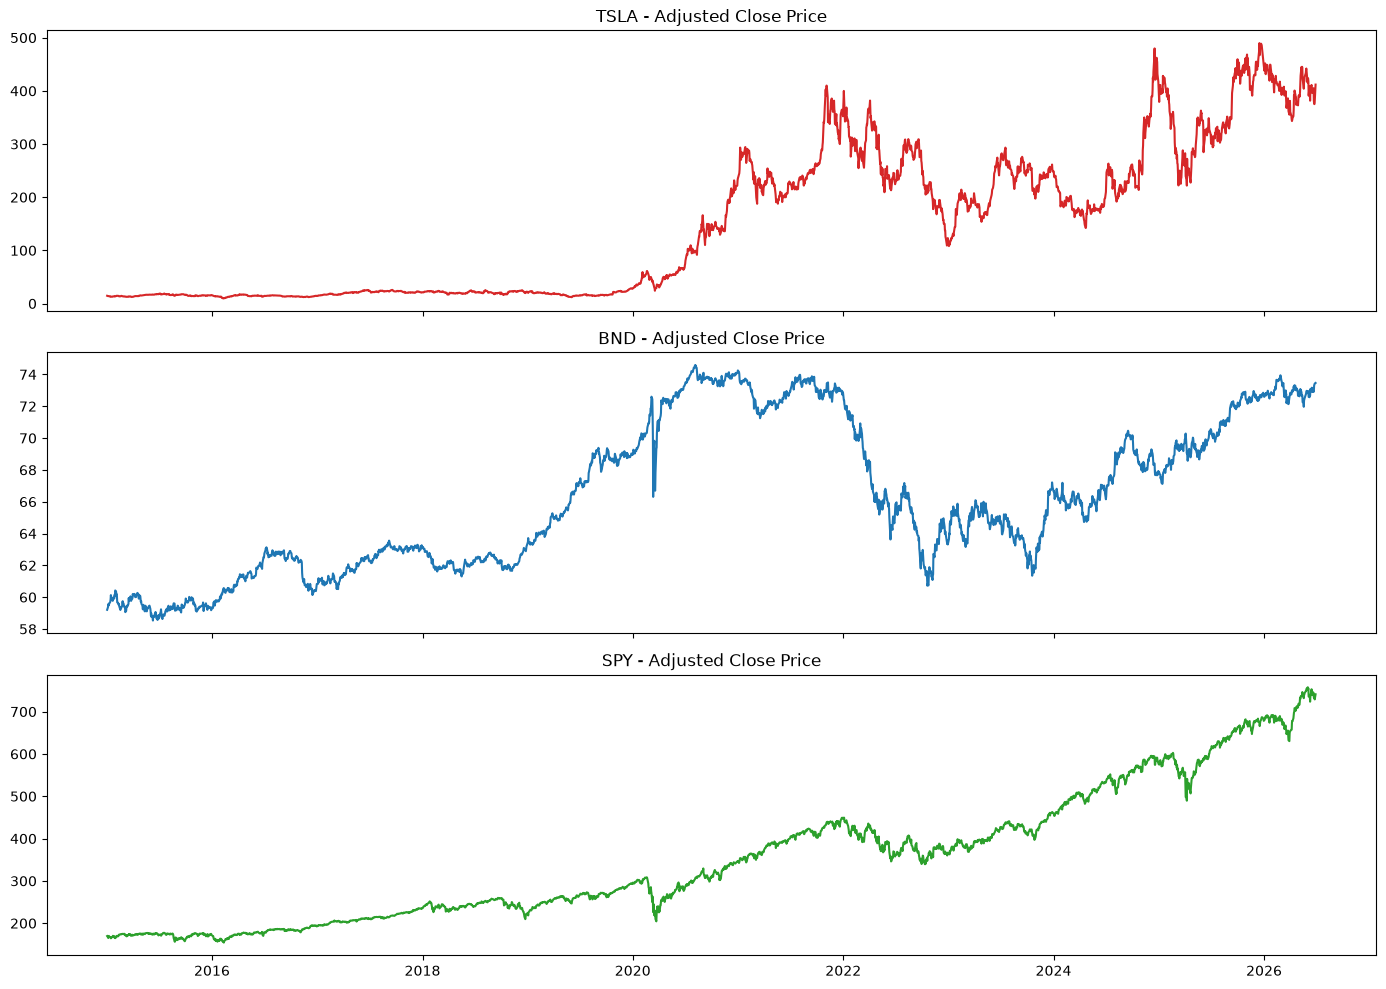

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(tsla.index, tsla["Adj Close"], color="tab:red")
axes[0].set_title("TSLA - Adjusted Close Price")

axes[1].plot(bnd.index, bnd["Adj Close"], color="tab:blue")
axes[1].set_title("BND - Adjusted Close Price")

axes[2].plot(spy.index, spy["Adj Close"], color="tab:green")
axes[2].set_title("SPY - Adjusted Close Price")

plt.tight_layout()
plt.show()

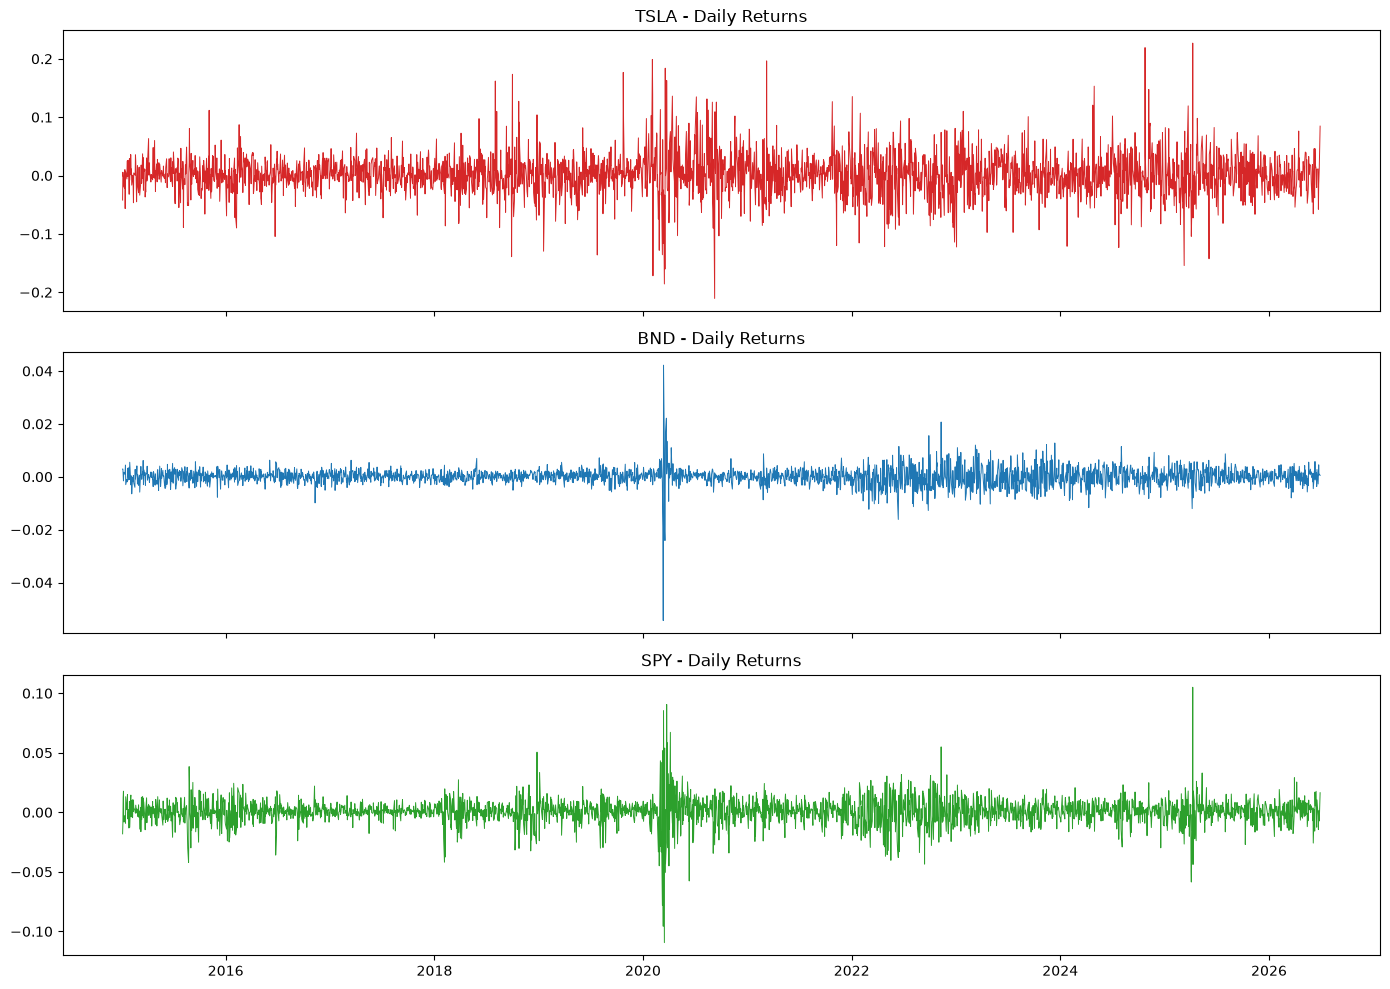

In [10]:
tsla["Daily Return"] = tsla["Adj Close"].pct_change()
bnd["Daily Return"] = bnd["Adj Close"].pct_change()
spy["Daily Return"] = spy["Adj Close"].pct_change()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(tsla.index, tsla["Daily Return"], color="tab:red", linewidth=0.7)
axes[0].set_title("TSLA - Daily Returns")

axes[1].plot(bnd.index, bnd["Daily Return"], color="tab:blue", linewidth=0.7)
axes[1].set_title("BND - Daily Returns")

axes[2].plot(spy.index, spy["Daily Return"], color="tab:green", linewidth=0.7)
axes[2].set_title("SPY - Daily Returns")

plt.tight_layout()
plt.show()

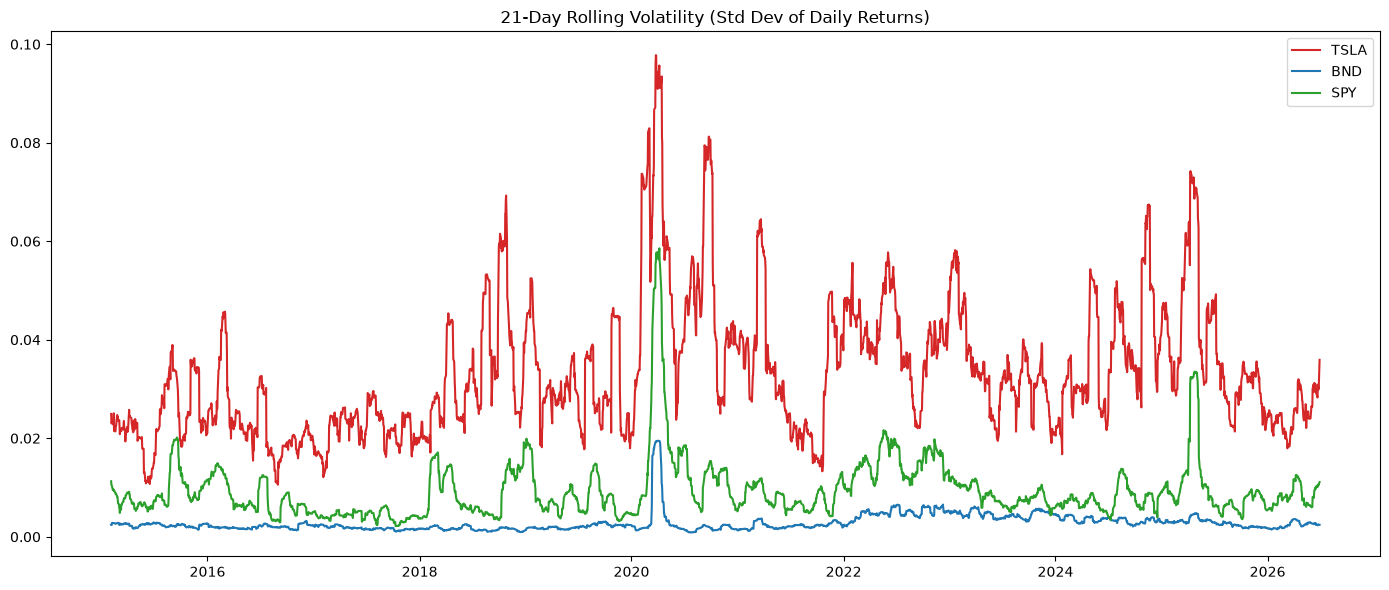

In [11]:
# 21-day rolling window ≈ 1 trading month
tsla["Rolling Volatility"] = tsla["Daily Return"].rolling(window=21).std()
bnd["Rolling Volatility"] = bnd["Daily Return"].rolling(window=21).std()
spy["Rolling Volatility"] = spy["Daily Return"].rolling(window=21).std()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(tsla.index, tsla["Rolling Volatility"], color="tab:red", label="TSLA")
ax.plot(bnd.index, bnd["Rolling Volatility"], color="tab:blue", label="BND")
ax.plot(spy.index, spy["Rolling Volatility"], color="tab:green", label="SPY")
ax.set_title("21-Day Rolling Volatility (Std Dev of Daily Returns)")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
def get_outliers(df, name, threshold=3):
    mean = df["Daily Return"].mean()
    std = df["Daily Return"].std()
    outliers = df[(df["Daily Return"] - mean).abs() > threshold * std]
    print(f"\n{name}: {len(outliers)} outlier days (>{threshold} std devs)")
    return outliers[["Daily Return"]].sort_values("Daily Return")

tsla_outliers = get_outliers(tsla, "TSLA")
bnd_outliers = get_outliers(bnd, "BND")
spy_outliers = get_outliers(spy, "SPY")

print(tsla_outliers)


TSLA: 46 outlier days (>3 std devs)

BND: 33 outlier days (>3 std devs)

SPY: 39 outlier days (>3 std devs)
Price       Daily Return
Date                    
2020-09-08     -0.210628
2020-03-16     -0.185778
2020-02-05     -0.171758
2020-03-18     -0.160344
2025-03-10     -0.154262
2025-06-05     -0.142599
2018-09-28     -0.139015
2019-07-25     -0.136137
2020-03-09     -0.135725
2019-01-18     -0.129711
2020-02-27     -0.128146
2024-07-24     -0.123346
2023-01-03     -0.122422
2022-04-26     -0.121841
2024-01-25     -0.121253
2021-11-09     -0.119903
2020-03-12     -0.116172
2022-01-27     -0.115542
2022-12-27     -0.114089
2018-08-07      0.109886
2023-01-27      0.110002
2015-11-04      0.111735
2020-08-17      0.112031
2020-03-02      0.113220
2025-03-24      0.119336
2024-04-24      0.120611
2020-08-31      0.125689
2020-09-14      0.125832
2021-10-25      0.126616
2018-10-23      0.127189
2020-08-12      0.131236
2020-07-06      0.134794
2022-01-03      0.135317
2020-04-13      

In [13]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\n{name}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Stationary" if result[1] < 0.05 else "Non-Stationary")

adf_test(tsla["Adj Close"], "TSLA - Close Price")
adf_test(tsla["Daily Return"], "TSLA - Daily Return")
adf_test(spy["Adj Close"], "SPY - Close Price")
adf_test(spy["Daily Return"], "SPY - Daily Return")
adf_test(bnd["Adj Close"], "BND - Close Price")
adf_test(bnd["Daily Return"], "BND - Daily Return")


TSLA - Close Price
ADF Statistic: -1.0696
p-value: 0.7270
Non-Stationary

TSLA - Daily Return
ADF Statistic: -53.9719
p-value: 0.0000
Stationary

SPY - Close Price
ADF Statistic: 1.3089
p-value: 0.9967
Non-Stationary

SPY - Daily Return
ADF Statistic: -17.5722
p-value: 0.0000
Stationary

BND - Close Price
ADF Statistic: -1.0479
p-value: 0.7354
Non-Stationary

BND - Daily Return
ADF Statistic: -15.2212
p-value: 0.0000
Stationary


In [14]:
import numpy as np

def risk_metrics(df, name, risk_free_rate=0.04):
    returns = df["Daily Return"].dropna()
    
    # VaR: 95% historical — the loss threshold you'd expect to exceed only 5% of the time
    var_95 = np.percentile(returns, 5)
    
    # Sharpe Ratio: annualized
    annual_return = returns.mean() * 252
    annual_std = returns.std() * np.sqrt(252)
    sharpe = (annual_return - risk_free_rate) / annual_std
    
    print(f"\n{name}")
    print(f"Daily VaR (95%): {var_95:.4f}  →  on the worst 5% of days, expect to lose at least {abs(var_95)*100:.2f}%")
    print(f"Annualized Return: {annual_return*100:.2f}%")
    print(f"Annualized Volatility: {annual_std*100:.2f}%")
    print(f"Sharpe Ratio: {sharpe:.3f}")

risk_metrics(tsla, "TSLA")
risk_metrics(bnd, "BND")
risk_metrics(spy, "SPY")


TSLA
Daily VaR (95%): -0.0517  →  on the worst 5% of days, expect to lose at least 5.17%
Annualized Return: 45.42%
Annualized Volatility: 57.18%
Sharpe Ratio: 0.724

BND
Daily VaR (95%): -0.0048  →  on the worst 5% of days, expect to lose at least 0.48%
Annualized Return: 2.03%
Annualized Volatility: 5.31%
Sharpe Ratio: -0.372

SPY
Daily VaR (95%): -0.0167  →  on the worst 5% of days, expect to lose at least 1.67%
Annualized Return: 14.43%
Annualized Volatility: 17.65%
Sharpe Ratio: 0.591


In [15]:
tsla.to_csv("../data/processed/tsla.csv")
bnd.to_csv("../data/processed/bnd.csv")
spy.to_csv("../data/processed/spy.csv")